## Plotting routine for global plots

In [30]:
# Imports packages
import matplotlib
from matplotlib.pyplot import pcolormesh

matplotlib.use("Agg")

import matplotlib
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
import warnings

In [20]:
# Load the data
data_slabctr = xr.open_dataset("LessOzone_Real_Analysis/slabctr_3D_REGRID_2000-2035.nc")   # Slab control run
data = xr.open_dataset("LessOzone_Real_Analysis/LessOzone_Real_3D_REGRID_2000-2035.nc")    # Our simulation

# Adjusts the calendar-format of the slab control run
date_floats = data_slabctr["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
data_slabctr = (data_slabctr.assign_coords(time=date_dt))

# Drop the first month of the slabctr (Jan 2000; We don't have this one)
data_slabctr = data_slabctr.isel(time=slice(1, None))

# Adjusts the calendar-format of our run
date_floats = data["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
data = (data.assign_coords(time=date_dt))

In [21]:
# Zonal mean
data_slabctr_zonmean = data_slabctr.mean(dim="lon")
data_zonmean = data.mean(dim="lon")

In [85]:
# Temporal mean (grouped by month)
data_slabctr_zonmean_monthly = data_slabctr_zonmean.groupby("time.month").mean(dim="time")  # Slab Control
data_zonmean_monthly = data_zonmean.groupby("time.month").mean(dim="time")  # Our simulation

In [ ]:
# --------------------------------------------------------------------------------------------------------------
# Plotting routine for individual months -----------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------------------

In [110]:
# Variable & Time
VariableName = "ta"
time = "2000-04-01T00:00:00.000000000"
# Please recognize that 2000 is 1989 (11 year shift)

# Labels
title = f"Vertical temperature differences (zonal mean) – {time[:10]}"
colorbarlabel = "Temperature difference [K]"
xlabel = "Latitude [°N]"
ylabel = "Height Level"

# Creates the array for the plot
plotdata = data_zonmean[VariableName].sel(time=time[:10]) - data_slabctr_zonmean[VariableName].sel(time=time[:10])

# Design
colormap = "coolwarm"
vval = max(np.abs(plotdata.values.min()), np.abs(plotdata.values.max())) # Automatic adjustment of the boundaries of the colorbar
norm = mcolors.TwoSlopeNorm(vmin=-vval, vcenter=0, vmax=vval) # Only if the colormap is diverging!

In [111]:
# T-Test
# Extract months
month = int(time[5:7])

# Select all timesteps from the selected month
run_monthly  = data_zonmean[VariableName].sel(time=data_zonmean.time.dt.month == month).values        # (n_years, height, lat)
ctrl_monthly = data_slabctr_zonmean[VariableName].sel(time=data_slabctr_zonmean.time.dt.month == month).values  # (n_years, height, lat)

# t-Test across all years (axis=0) → p_values Shape: (height, lat)
_, p_values = stats.ttest_ind(run_monthly, ctrl_monthly, axis=0)
not_significant = p_values >= 0.05

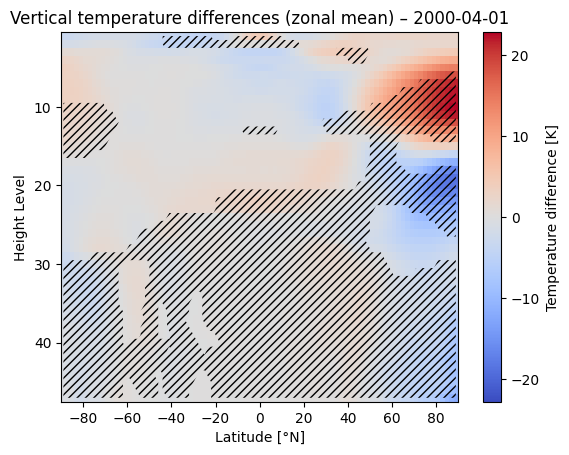

In [83]:
%matplotlib inline

pcm = plt.pcolormesh(
        plotdata.lat,
        plotdata.height,
        plotdata,
        shading="auto",
        cmap=colormap,
        norm=norm
)

# Marking the non-significant areas
plt.contourf(
    plotdata.lat,
    plotdata.height,
    not_significant.astype(float),
    levels=[0.5, 1.5],
    hatches=["////"],
    colors="none",
)

plt.colorbar(pcm, label=colorbarlabel)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.gca().invert_yaxis()  # Level 1 oben, höchstes Level unten
#plt.savefig(f"Tempprofile_{time[:10]}") # Need to adjust this one!
plt.show()

In [ ]:
# --------------------------------------------------------------------------------------------------------------
# Plotting routine for monthly groups --------------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------------------

In [162]:
monthlist = ["January", "February", "March", "April", "May", "June", "July",
             "August", "September", "October", "November", "December"]

# Variable & Time
VariableName = "ua"
time = 8 # 1 = Jan, 2 = Feb, ...
# Please recognize that 2000 is 1989 (11 year shift)

# Labels
title = f"Eastward Wind (zonal & temporal mean) – {monthlist[time-1]}"
colorbarlabel = "Eastward Wind [m/s]"
xlabel = "Latitude [°N]"
ylabel = "Height Level"

# Creates the array for the plot
plotdata = data_zonmean_monthly[VariableName].sel(month=time) - data_slabctr_zonmean_monthly[VariableName].sel(month=time)

# Design
colormap = "PRGn"
vval = max(np.abs(plotdata.values.min()), np.abs(plotdata.values.max())) # Automatic adjustment of the boundaries of the colorbar
norm = mcolors.TwoSlopeNorm(vmin=-vval, vcenter=0, vmax=vval) # Only if the colormap is diverging!

In [163]:
# T-Test
# Extract months

# Select all timesteps from the selected month
run_monthly  = data_zonmean[VariableName].sel(time=data_zonmean.time.dt.month == time).values   # (n_years, height, lat)
ctrl_monthly = data_slabctr_zonmean[VariableName].sel(time=data_slabctr_zonmean.time.dt.month == time).values  # (n_years, height, lat)

# t-Test across all years (axis=0) → p_values Shape: (height, lat)
_, p_values = stats.ttest_ind(run_monthly, ctrl_monthly, axis=0)
not_significant = p_values >= 0.05

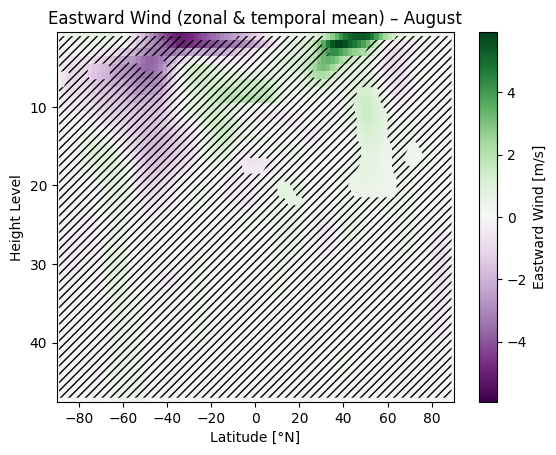

In [164]:
pcm = plt.pcolormesh(
        plotdata.lat,
        plotdata.height,
        plotdata,
        shading="auto",
        cmap=colormap,
        norm=norm
)

# Marking the non-significant areas
plt.contourf(
    plotdata.lat,
    plotdata.height,
    not_significant.astype(float),
    levels=[0.5, 1.5],
    hatches=["////"],
    colors="none",
)

plt.colorbar(pcm, label=colorbarlabel)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(title)
plt.gca().invert_yaxis()  # Level 1 = uppermost layer
#plt.savefig(f"Eastward_wind_monthly_{monthlist[time-1]}") # Need to adjust this one!
plt.show()

In [ ]:
# --------------------------------------------------------------------------------------------------------------
# OLD CODE BELOW HERE! -----------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------------------------------

In [109]:
print(run_monthly.shape)   # sollte (35, height, lat) sein
print(ctrl_monthly.shape)

(0, 47, 90)
(0, 47, 90)


In [144]:
data_slabctr_zonmean.info

<bound method Dataset.info of <xarray.Dataset> Size: 78MB
Dimensions:      (height: 47, bnds: 2, lat: 90, time: 420)
Coordinates:
  * height       (height) float64 376B 1.0 2.0 3.0 4.0 ... 44.0 45.0 46.0 47.0
  * lat          (lat) float64 720B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * time         (time) datetime64[ns] 3kB 2000-02-01 2000-03-01 ... 2035-01-01
Dimensions without coordinates: bnds
Data variables: (12/14)
    height_bnds  (height, bnds) float64 752B 1.0 2.0 2.0 3.0 ... 47.0 47.0 48.0
    zg           (height, lat) float32 17kB 8.005e+04 8.005e+04 ... 20.05 20.03
    ps           (time, lat) float32 151kB 6.851e+04 6.947e+04 ... 1.02e+05
    pfull        (time, height, lat) float32 7MB 0.8851 0.884 ... 1.018e+05
    rho          (time, height, lat) float32 7MB 1.968e-05 1.967e-05 ... 1.467
    ta           (time, height, lat) float32 7MB 157.5 157.4 ... 241.4 241.9
    ...           ...
    wap          (time, height, lat) float32 7MB -4.891e-06 ... -0.001881
    hus

In [112]:
int("01")

1

In [69]:
not_significant

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [156]:
data.info()

xarray.Dataset {
dimensions:
	height = 47 ;
	bnds = 2 ;
	lat = 90 ;
	lon = 180 ;
	time = 420 ;

variables:
	float64 height_bnds(height, bnds) ;
	float32 zg(height, lat, lon) ;
		zg:standard_name = geometric_height_at_full_level_center ;
		zg:long_name = geometric height at full level center ;
		zg:units = m ;
		zg:param = 6.3.0 ;
	float32 ps(time, lat, lon) ;
		ps:standard_name = surface_air_pressure ;
		ps:long_name = surface pressure ;
		ps:units = Pa ;
		ps:param = 0.3.0 ;
	float32 pfull(time, height, lat, lon) ;
		pfull:standard_name = air_pressure ;
		pfull:long_name = Pressure ;
		pfull:units = Pa ;
		pfull:param = 0.3.0 ;
	float32 rho(time, height, lat, lon) ;
		rho:standard_name = air_density ;
		rho:long_name = density ;
		rho:units = kg m-3 ;
		rho:param = 10.3.0 ;
	float32 ta(time, height, lat, lon) ;
		ta:standard_name = air_temperature ;
		ta:long_name = Temperature ;
		ta:units = K ;
		ta:param = 0.0.0 ;
	float32 ua(time, height, lat, lon) ;
		ua:standard_name = eastward_